# Feature Sifting — online feature search

This notebook studies the **feature sifting** task (`phd/jax_core/tasks/feature_sifting.py`): an online
single-sample regression problem where the learner observes `n_learner_features` noisy candidate features,
each a noisy view of one of `n_target_features` true features. The target is a fixed weighted sum (weights
±1) of the true features. The learner predicts the target with a **linear model** and, each step, may mark
candidate slots for replacement (`prune_mask`); pruned slots are regenerated by the task with a fresh random
target index and noise coefficient. The learner must continually *sift* useful (low-noise) candidates from
useless ones.

### Methods compared
1. **LMS** — SGD on the squared error over a **fixed** candidate set (never prunes). Pure online linear
   regression; the baseline with no feature search.
2. **CBP + Adam** — continual-backprop feature recycling on top of an Adam base optimizer.
3. **CBP + Autostep** — continual-backprop feature recycling on top of the Autostep (IDBD) optimizer.
4. **Fable** — *placeholder*, added later.

**Continual backprop (CBP).** A replacement rate `r` accumulates `r · n_features` per step; once the
accumulator reaches 1, the lowest-**utility** candidate is pruned. Utility is an EMA (decay rate `β`) of
`|weight| · |feature|`. A reset feature gets utility = the **median** of the current utilities (so it is not
re-pruned immediately), its weight is zeroed, and — importantly — **its optimizer state is reset** (Adam
moments → 0; Autostep step-size/trace → initial).

### How sweeping / caching works
Each method is run as an **mlflow-sweeper** grid sweep (programmatic `run_sweep`). Every configuration runs
`N` seeds batched in a single `jax.lax.scan` (jitted end-to-end) and logs the binned learning curve
(`loss`, `loss_std` = mean / std across seeds) plus a scalar `final_loss`. Because the sweeps and metrics
live in local MLflow/Optuna stores, **the experiments only run on the first execution** — re-running the
notebook finds the studies complete and just reloads the cached data.

In [1]:
import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import mlflow
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.optimizers.adam import custom_optax_adam, AdamState
from phd.jax_core.utils import tree_replace

from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import (
    load_experiment_data, get_best_ablation_values, get_color_palette,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Storage is kept in local files **relative to this notebook**, so the sweep state and logged metrics persist
across runs. Adjust `NUM_STEPS` / seed counts / grids below to trade off runtime vs. resolution.

In [2]:
EXPERIMENT = 'feature_sifting'
NOTEBOOK_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
MLFLOW_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'mlruns.db')}"
OPTUNA_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'optuna.db')}"

os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_URI
mlflow.set_tracking_uri(MLFLOW_URI)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SWEEP_OUTPUT_DIR, exist_ok=True)

# Task / training configuration.
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 0.0
NUM_STEPS = 50_000
BASE_SEED = 0
N_SWEEP_SEEDS = 5       # seeds batched per sweep configuration
N_CURVE_SEEDS = 30      # seeds for the final best-config learning curves
N_LOG_POINTS = 250      # binned points logged per run (learning-curve resolution)
FINAL_FRACTION = 0.05   # last 5% of steps define the summary 'final loss'

# Loss of the trivial predictor (always predicts 0): E[y^2]. Each target weight is +-1
# and target features are uniform[-1, 1] (variance 1/3). Anything that learns beats this;
# anything that diverges exceeds it. Used as the convergence threshold for sensitivity plots.
BASELINE_LOSS = N_TARGET_FEATURES / 3.0 + TARGET_NOISE_STD ** 2

# Portion of the sweep config shared by every method.
BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store :', MLFLOW_URI)
print('Baseline loss:', round(BASELINE_LOSS, 4))

MLflow store : sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/output/mlruns.db
Baseline loss: 3.3333


## Core: the learner and shared CBP primitives

A single linear layer `w` of shape `(1, n_learner_features)` predicts `y_hat = w · x` — the natural learner
for this task, and Autostep-compatible (2D weight, no bias). The loss is the squared prediction error on the
freshly observed sample.

**Method interface.** Each method (one per cell below) is an `eqx.Module` that bundles its own `init` and
`step`:

* `Method.init(hparams, key) -> Method` builds the optimizer, weights, and any algorithm state. Static
  hyperparameters (the optimizer, replacement / decay rates) are `eqx.field(static=True)`; the dynamic state
  (weights, optimizer state, utilities, …) are ordinary array fields.
* `method.step(x, y) -> (method, loss)` predicts, learns, and returns the updated module. It also carries a
  `prune_mask` field telling the task which candidate slots to regenerate next (all-`False` for methods that
  never recycle).

Because each module carries its own (static) config, the training loop is method-agnostic — it only calls
`init` / `step` and routes `prune_mask` to the task. The cell below holds the pieces shared across methods:
`reset_opt_state` (reset a recycled feature's optimizer state) and `recycle_features` (the continual-backprop
generate-and-test step).

In [3]:
def reset_opt_state(opt_state, prune_mask):
    """Reset per-feature optimizer state for pruned (regenerated) features."""
    m = prune_mask[None, :]  # broadcast over the single output row -> (1, n_features)
    if isinstance(opt_state, AdamState):
        return AdamState(
            lr=opt_state.lr,
            step=jnp.where(m, 0, opt_state.step),
            exp_avg=jnp.where(m, 0.0, opt_state.exp_avg),
            exp_avg_sq=jnp.where(m, 0.0, opt_state.exp_avg_sq),
        )
    if isinstance(opt_state, IDBDState):
        return IDBDState(
            init_beta=opt_state.init_beta,
            beta=jnp.where(m, opt_state.init_beta, opt_state.beta),  # step-size -> initial
            h=jnp.where(m, 0.0, opt_state.h),
            v=jnp.where(m, 0.0, opt_state.v),
        )
    return opt_state  # SGD (LMS): stateless, nothing to reset


def linear_loss_and_grads(w, x, y):
    """Squared-error loss of the linear prediction and its exact gradient wrt `w`."""
    y_hat = jnp.sum(w * x[None, :])
    error = y_hat - y
    return error ** 2, 2.0 * error * x[None, :]


def recycle_features(w, opt_state, util, accum, replace_rate):
    """Continual-backprop recycling. Accumulate the replacement budget (`replace_rate` * n
    per call) and, once it reaches one whole feature, recycle the lowest-utility slot(s):
    zero the weight, reset the optimizer state, and set the utility to the median so the
    fresh slot is not immediately re-pruned. Returns the updated
    `(w, opt_state, util, accum, prune_mask)`; `prune_mask` marks the slots the task should
    regenerate on the next observation."""
    n = util.shape[0]
    accum = accum + replace_rate * n
    n_avail = jnp.floor(accum).astype(jnp.int32)
    rank = jnp.argsort(jnp.argsort(util))       # 0 = lowest utility
    prune_mask = rank < n_avail
    accum = accum - jnp.sum(prune_mask)
    w = jnp.where(prune_mask[None, :], 0.0, w)
    util = jnp.where(prune_mask, jnp.median(util), util)
    opt_state = reset_opt_state(opt_state, prune_mask)
    return w, opt_state, util, accum, prune_mask

## Sweep infrastructure

`MethodSpec` records a method's class, default hyperparameters, and label; each method registers itself in
`METHODS` from its own cell. `run_all_seeds` runs every seed of a config batched in a single jitted
`jax.lax.scan` — the loop only calls the module's `init` / `step` and routes `prune_mask` to the task.
`run_method_sweep` turns a grid into a programmatic mlflow-sweeper sweep (the objective fills in `defaults`
for any hyperparameter the grid does not sweep, and logs via `log_run`); `load_sweep_data` returns the
standard `config_dfs` / `run_dfs` dicts, downloading only when new runs have appeared.

In [4]:
import sys
if NOTEBOOK_DIR not in sys.path:           # make the sibling experiment_logging.py importable
    sys.path.insert(0, NOTEBOOK_DIR)
from experiment_logging import log_run, summarize_runs, plot_sensitivity, plot_learning_curve


@dataclass
class MethodSpec:
    name: str          # mlflow sweep_name
    label: str         # human-readable label for plots
    cls: type          # eqx.Module with .init(hparams, key) and .step(x, y) -> (module, loss)
    defaults: dict     # default hyperparameters; the grid overrides the subset it sweeps


METHODS = {}           # each method's cell below registers itself here


def swept_vars(grid):
    """The grid keys that actually vary (more than one value) — the swept hyperparameters."""
    return [k for k, vals in grid.items() if len(vals) > 1]


def run_all_seeds(method_cls, hparams, n_seeds):
    """Run `n_seeds` seeds (batched + jitted) of `method_cls` at `hparams`; losses (n_seeds, NUM_STEPS)."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)     # task regenerates the recycled slots
            state, loss = state.step(x, jnp.squeeze(y))
            return (task, state), loss

        _, losses = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return losses

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def make_objective(spec):
    def objective(**params):
        n_seeds = int(params.pop('n_seeds'))
        hparams = {**spec.defaults, **{k: float(v) for k, v in params.items()}}
        return log_run(run_all_seeds(spec.cls, hparams, n_seeds), N_LOG_POINTS, FINAL_FRACTION)
    return objective


def run_method_sweep(spec, grid, n_seeds, sweep_name=None, n_jobs=1):
    sweep_name = sweep_name or spec.name
    params = dict(grid)
    params['n_seeds'] = int(n_seeds)
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': sweep_name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running an already-complete sweep doesn't raise
    # "Run ... is already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()
    # allow_param_change updates the sweep in place when the config differs from the stored
    # one — e.g. after moving the MLflow/Optuna stores, or after editing a grid. Matching
    # trials are migrated (no recompute); only new/removed grid points actually run.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True, no_plots=True,
              allow_param_change=True, executor='thread')


PARAMS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, '.run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when needed.

    The download is skipped (cached CSVs are reloaded) whenever no new finished runs
    have appeared since the last download, so re-running analysis cells does not
    re-download. Pass ``force_download=True`` to force a fresh download.
    """
    n_runs = _n_finished_runs()
    have_csv = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    cached_n = int(open(RUN_COUNT_MARKER).read()) if os.path.exists(RUN_COUNT_MARKER) else -1
    if force_download or not have_csv or n_runs != cached_n:
        download_experiment(EXPERIMENT, output_dir=DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))
    else:
        print(f'Reusing cached CSVs ({n_runs} runs, no new data to download).')
    return load_experiment_data(PARAMS_CSV, METRICS_CSV)


def best_hparams(cfgs, runs, spec, grid):
    """Best (min final-avg loss) hyperparameters for a method's grid sweep."""
    sv = swept_vars(grid)
    _, _, best = get_best_ablation_values(
        {spec.name: cfgs[spec.name]}, {spec.name: runs[spec.name]},
        sweep_ablation_vars={spec.name: sv},
        metric_col='loss', metric_direction='min', metric_type='final_avg',
        nan_policy='propagate', print_best_values=False,
    )
    return {key: float(val) for key, val in best[spec.name].items()}

## 1. LMS

Plain online linear regression (SGD) on the **fixed** initial candidate set. Sweeps the step-size only.

In [5]:
class LMS(eqx.Module):
    """LMS — SGD on a fixed candidate set; never recycles features."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        optimizer = optax.sgd(hparams['learning_rate'])
        w = jnp.zeros((1, N_LEARNER_FEATURES))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(N_LEARNER_FEATURES, dtype=bool))

    def step(self, x, y):
        loss, grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update(grads, self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        return tree_replace(self, w=w, opt_state=opt_state), loss   # prune_mask stays all-False


LMS_DEFAULTS = {'learning_rate': 2.0 ** -12}
METHODS['lms'] = MethodSpec('lms', 'LMS', LMS, LMS_DEFAULTS)

[I 2026-06-13 18:28:36,897] Using an existing study with name 'feature_sifting/lms' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 6d438ee83f1c410c8c076972cf52ddc6.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting' (id=1)
INFO:phd.research_utils.scripts.mlflow_download:Found 196 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 196/196 [00:29<00:00,  6.63it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 196 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_si

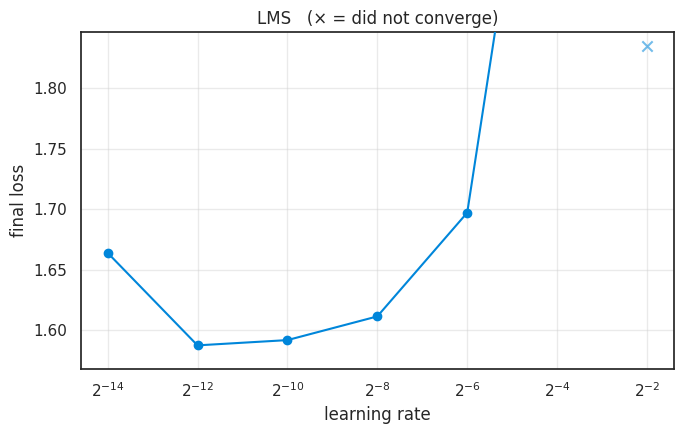

In [6]:
LMS_GRID = {'learning_rate': [2.0 ** e for e in range(-14, -3, 2)]}   # 2^-14 .. 2^-4

run_method_sweep(METHODS['lms'], LMS_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
lms_summary = summarize_runs(cfgs, runs, 'lms', swept_vars(LMS_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(lms_summary, swept_vars(LMS_GRID), 'LMS')
plt.show()

### LMS — best configuration learning curve (30 seeds)

[I 2026-06-13 18:29:07,735] Using an existing study with name 'feature_sifting/lms_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 77d9089e08b84418b4541cb2fd392544.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


LMS best: {'learning_rate': 0.000244140625}
Reusing cached CSVs (196 runs, no new data to download).


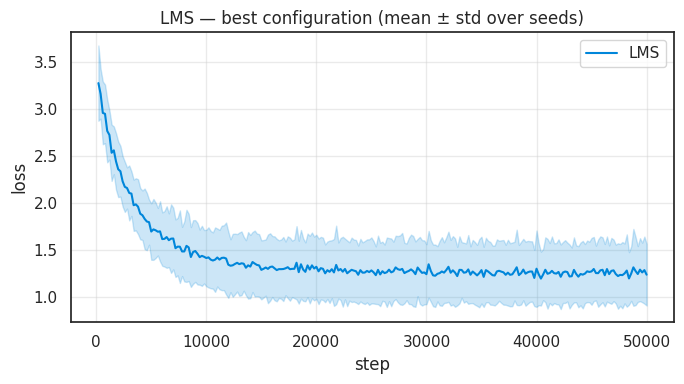

In [7]:
lms_best = best_hparams(cfgs, runs, METHODS['lms'], LMS_GRID)
print('LMS best:', lms_best)
run_method_sweep(METHODS['lms'], lms_best, N_CURVE_SEEDS, sweep_name='lms_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'lms_best', label='LMS', color=get_color_palette(n=1)[0])
plt.title('LMS — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. CBP + Adam

Continual-backprop feature recycling on an Adam base. Sweeps step-size, replacement rate, and utility EMA
decay rate (3 vars → profile-best sensitivity panels).

In [8]:
class CBPAdam(eqx.Module):
    """CBP + Adam — continual-backprop feature recycling on an Adam base optimizer."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    replace_rate: float = eqx.field(static=True)
    decay_rate: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    util: jax.Array
    accum: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = custom_optax_adam(hparams['learning_rate'])
        w = jnp.zeros((1, n))
        # accum starts at one step's budget so recycling (decided at the end of step,
        # gating the next sample) stays on the same schedule as a start-of-step decision.
        return cls(optimizer=optimizer, replace_rate=hparams['replace_rate'],
                   decay_rate=hparams['decay_rate'], w=w, opt_state=optimizer.init(w),
                   util=jnp.zeros(n), accum=jnp.array(hparams['replace_rate'] * n),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update(loss_grads, self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        util = (1.0 - self.decay_rate) * (jnp.abs(w[0]) * jnp.abs(x)) + self.decay_rate * self.util
        w, opt_state, util, accum, prune_mask = recycle_features(
            w, opt_state, util, self.accum, self.replace_rate)
        return tree_replace(self, w=w, opt_state=opt_state, util=util,
                            accum=accum, prune_mask=prune_mask), loss


CBP_ADAM_DEFAULTS = {'learning_rate': 2.0 ** -6, 'replace_rate': 1e-3, 'decay_rate': 0.9}
METHODS['cbp_adam'] = MethodSpec('cbp_adam', 'CBP + Adam', CBPAdam, CBP_ADAM_DEFAULTS)

[I 2026-06-13 18:29:08,194] Using an existing study with name 'feature_sifting/cbp_adam' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: ab4f1ebd1ec34333bacef003469e1269.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (196 runs, no new data to download).


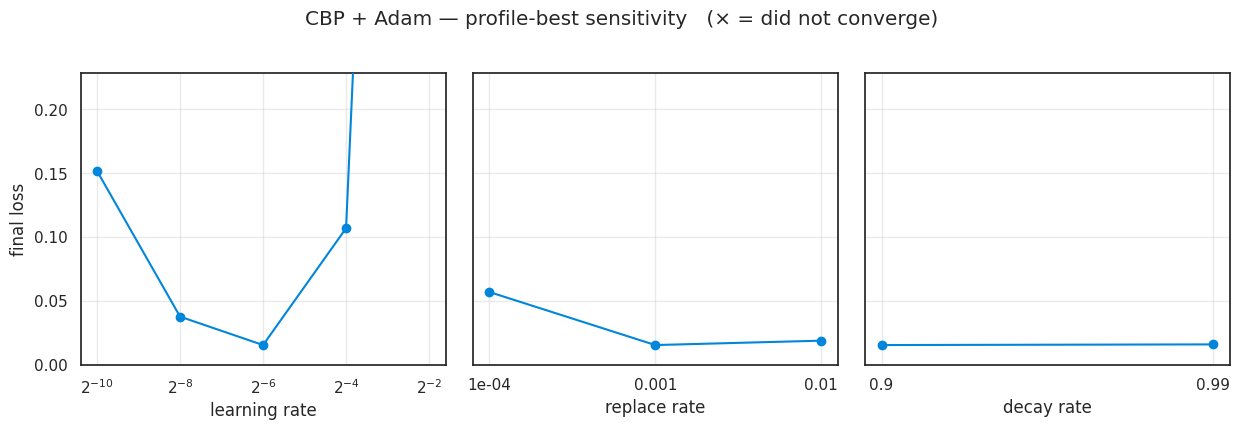

In [9]:
CBP_ADAM_GRID = {
    'learning_rate': [2.0 ** e for e in range(-10, -3, 2)],   # 2^-10 .. 2^-4
    'replace_rate': [1e-4, 1e-3, 1e-2],
    'decay_rate': [0.9, 0.99],
}
run_method_sweep(METHODS['cbp_adam'], CBP_ADAM_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
cbp_adam_summary = summarize_runs(cfgs, runs, 'cbp_adam', swept_vars(CBP_ADAM_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(cbp_adam_summary, swept_vars(CBP_ADAM_GRID), 'CBP + Adam')
plt.show()

### CBP + Adam — best configuration learning curve (30 seeds)

[I 2026-06-13 18:29:08,990] Using an existing study with name 'feature_sifting/cbp_adam_best' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 8d73b9a576b844a1a0358a0017b570d3.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


CBP + Adam best: {'learning_rate': 0.015625, 'replace_rate': 0.001, 'decay_rate': 0.9}
Reusing cached CSVs (196 runs, no new data to download).


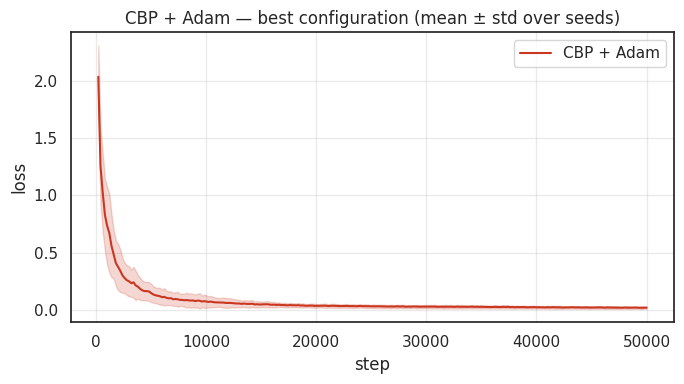

In [10]:
cbp_adam_best = best_hparams(cfgs, runs, METHODS['cbp_adam'], CBP_ADAM_GRID)
print('CBP + Adam best:', cbp_adam_best)
run_method_sweep(METHODS['cbp_adam'], cbp_adam_best, N_CURVE_SEEDS, sweep_name='cbp_adam_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'cbp_adam_best', label='CBP + Adam', color=get_color_palette(n=2)[1])
plt.title('CBP + Adam — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 3. CBP + Autostep

Continual-backprop feature recycling on the Autostep (IDBD) optimizer. Sweeps step-size, meta step-size,
replacement rate, and utility EMA decay rate (4 vars → profile-best sensitivity panels).

In [11]:
class CBPAutostep(eqx.Module):
    """CBP + Autostep — continual-backprop feature recycling on an Autostep (IDBD) base."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    replace_rate: float = eqx.field(static=True)
    decay_rate: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    util: jax.Array
    accum: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learniang_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, replace_rate=hparams['replace_rate'],
                   decay_rate=hparams['decay_rate'], w=w, opt_state=optimizer.init(w),
                   util=jnp.zeros(n), accum=jnp.array(hparams['replace_rate'] * n),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep/IDBD consumes both the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        util = (1.0 - self.decay_rate) * (jnp.abs(w[0]) * jnp.abs(x)) + self.decay_rate * self.util
        w, opt_state, util, accum, prune_mask = recycle_features(
            w, opt_state, util, self.accum, self.replace_rate)
        return tree_replace(self, w=w, opt_state=opt_state, util=util,
                            accum=accum, prune_mask=prune_mask), loss


CBP_AUTOSTEP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                         'replace_rate': 1e-3, 'decay_rate': 0.9}
METHODS['cbp_autostep'] = MethodSpec('cbp_autostep', 'CBP + Autostep', CBPAutostep, CBP_AUTOSTEP_DEFAULTS)

[I 2026-06-13 18:29:09,436] Using an existing study with name 'feature_sifting/cbp_autostep' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: cf49723570d94ba6b1dacab901100296.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (196 runs, no new data to download).


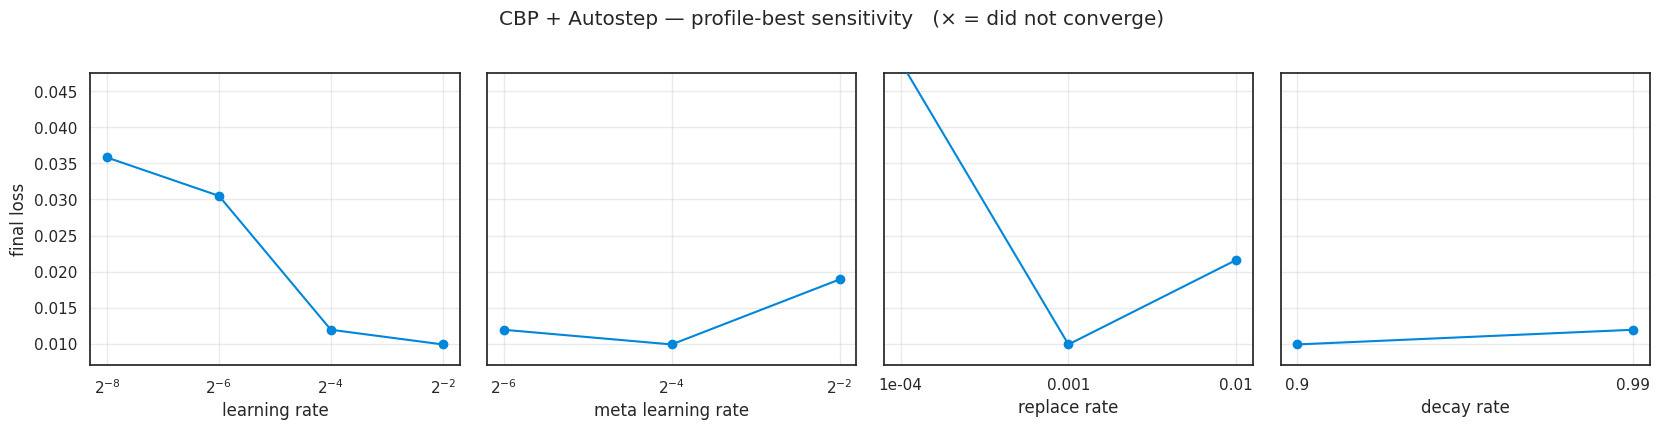

In [12]:
CBP_AUTOSTEP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],    # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],
    'replace_rate': [1e-4, 1e-3, 1e-2],
    'decay_rate': [0.9, 0.99],
}
run_method_sweep(METHODS['cbp_autostep'], CBP_AUTOSTEP_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
cbp_autostep_summary = summarize_runs(cfgs, runs, 'cbp_autostep', swept_vars(CBP_AUTOSTEP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(cbp_autostep_summary, swept_vars(CBP_AUTOSTEP_GRID), 'CBP + Autostep')
plt.show()

### CBP + Autostep — best configuration learning curve (30 seeds)

[I 2026-06-13 18:29:10,301] Using an existing study with name 'feature_sifting/cbp_autostep_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 788a8b57c9fa4bd4bef68e6bb2987db4.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


CBP + Autostep best: {'learning_rate': 0.25, 'meta_learning_rate': 0.0625, 'replace_rate': 0.001, 'decay_rate': 0.9}
Reusing cached CSVs (196 runs, no new data to download).


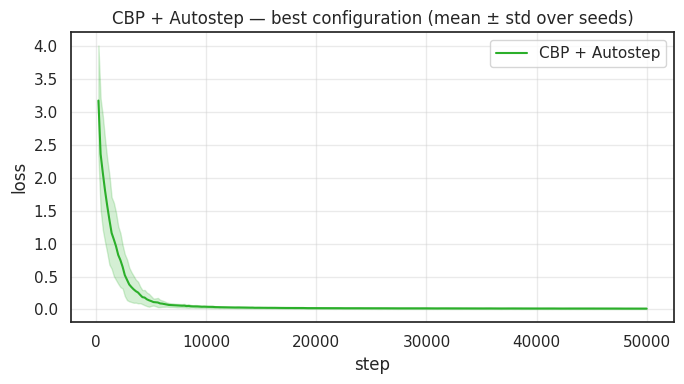

In [13]:
cbp_autostep_best = best_hparams(cfgs, runs, METHODS['cbp_autostep'], CBP_AUTOSTEP_GRID)
print('CBP + Autostep best:', cbp_autostep_best)
run_method_sweep(METHODS['cbp_autostep'], cbp_autostep_best, N_CURVE_SEEDS, sweep_name='cbp_autostep_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'cbp_autostep_best', label='CBP + Autostep', color=get_color_palette(n=3)[2])
plt.title('CBP + Autostep — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

# 3.5 Signed Utility CBP Autostep

In [14]:
class SUCBPAutostep(eqx.Module):
    """Signed Utility CBP + Autostep — continual-backprop feature recycling on an Autostep (IDBD) base."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    replace_rate: float = eqx.field(static=True)
    decay_rate: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    util: jax.Array
    accum: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, replace_rate=hparams['replace_rate'],
                   decay_rate=hparams['decay_rate'], w=w, opt_state=optimizer.init(w),
                   util=jnp.zeros(n), accum=jnp.array(hparams['replace_rate'] * n),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        contributions = x * jnp.squeeze(self.w)
        pred = jnp.sum(contributions)
        error = jnp.squeeze(y - pred)
        step_util = jnp.abs(error + contributions) - jnp.abs(error)
        util = (1.0 - self.decay_rate) * step_util + self.decay_rate * self.util
        
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep/IDBD consumes both the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        w, opt_state, util, accum, prune_mask = recycle_features(
            w, opt_state, util, self.accum, self.replace_rate)
        return tree_replace(self, w=w, opt_state=opt_state, util=util,
                            accum=accum, prune_mask=prune_mask), loss


SU_CBP_AUTOSTEP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                         'replace_rate': 1e-3, 'decay_rate': 0.99}
METHODS['sucbp_autostep'] = MethodSpec('sucbp_autostep', 'Signed Utility CBP + Autostep', SUCBPAutostep, SU_CBP_AUTOSTEP_DEFAULTS)

[I 2026-06-13 18:29:10,751] Using an existing study with name 'feature_sifting/sucbp_autostep' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 7a049c2a65364144bb2a520f39de690f.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (196 runs, no new data to download).


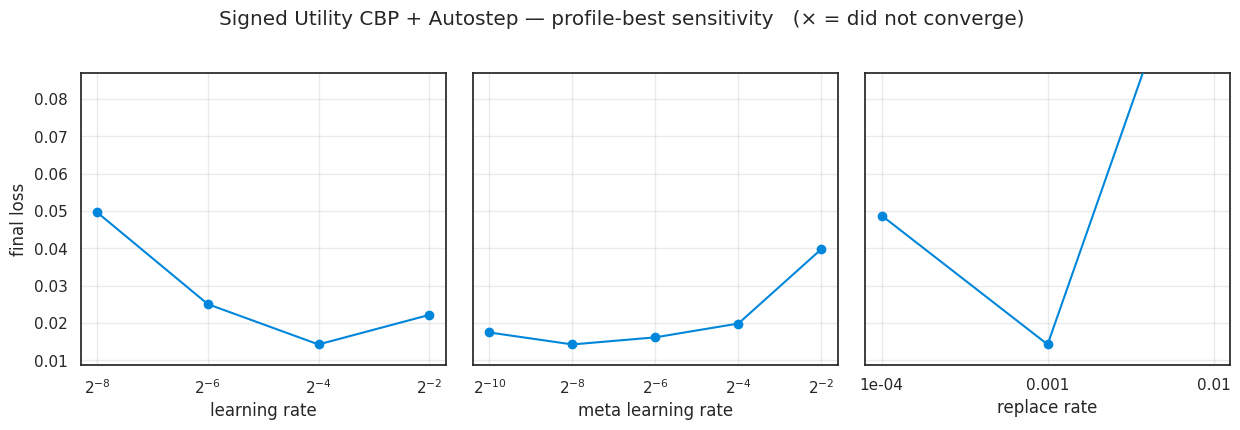

In [15]:
SU_CBP_AUTOSTEP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],    # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-10, -1, 2)],
    'replace_rate': [1e-4, 1e-3, 1e-2],
    # 'decay_rate': [0.9, 0.99],
}
run_method_sweep(METHODS['sucbp_autostep'], SU_CBP_AUTOSTEP_GRID, N_SWEEP_SEEDS, n_jobs=3)
cfgs, runs = load_sweep_data()
sucbp_autostep_summary = summarize_runs(cfgs, runs, 'sucbp_autostep', swept_vars(SU_CBP_AUTOSTEP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(sucbp_autostep_summary, swept_vars(SU_CBP_AUTOSTEP_GRID), 'Signed Utility CBP + Autostep')
plt.show()

[I 2026-06-13 18:29:11,348] Using an existing study with name 'feature_sifting/sucbp_autostep_best' instead of creating a new one.


Signed Utility CBP + Autostep best: {'learning_rate': 0.0625, 'meta_learning_rate': 0.00390625, 'replace_rate': 0.001}


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: d233929d9b7f49d2930b469243faf688.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (196 runs, no new data to download).


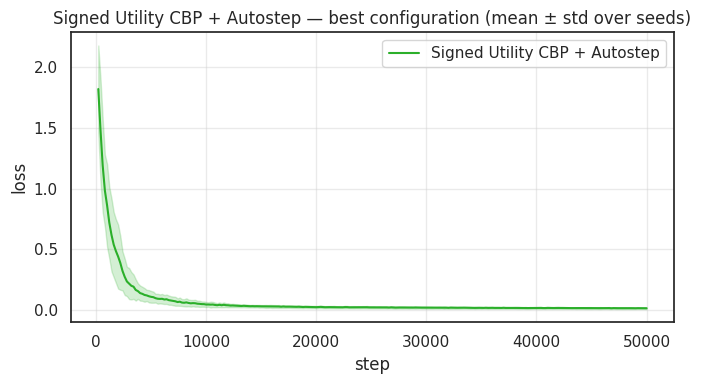

In [16]:
sucbp_autostep_best = best_hparams(cfgs, runs, METHODS['sucbp_autostep'], SU_CBP_AUTOSTEP_GRID)
print('Signed Utility CBP + Autostep best:', sucbp_autostep_best)
run_method_sweep(METHODS['sucbp_autostep'], sucbp_autostep_best, N_CURVE_SEEDS, sweep_name='sucbp_autostep_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'sucbp_autostep_best', label='Signed Utility CBP + Autostep', color=get_color_palette(n=3)[2])
plt.title('Signed Utility CBP + Autostep — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Fable (placeholder)

Not implemented yet. To add it, copy a method cell: define `class Fable(eqx.Module)` with an
`init(hparams, key)` classmethod and a `step(x, y) -> (self, loss)` method (mark static hyperparameters with
`eqx.field(static=True)`), a `FABLE_DEFAULTS` dict, and register it in `METHODS`. Then add a run cell with its
grid. If Fable recycles features and keeps per-feature optimizer state, extend `reset_opt_state` to handle its
state type.

In [17]:
# =============================================================================
# Fable — reservoir-index pruning by sequential confidence-bound tests.
#
# Paste this into the "## 4. Fable" method cell of feature_sifting_experiments.ipynb
# (replacing the placeholder). It assumes the notebook globals already exist:
#   jax, jnp, eqx, tree_replace, N_LEARNER_FEATURES, MethodSpec, METHODS.
# A suggested run / learning-curve cell is given (commented) at the bottom.
#
# One uniform loop, identical on every step (including t = 0): learn -> measure ->
# bound -> compute the bar z* -> record resolved tests -> prune at most the single
# worst feature below the bar. Per feature we keep a weight, three running averages,
# an age, and one bookkeeping bit; globally a small record R of how good fresh draws
# turned out to be. Cold start needs no special handling: an empty R gives z* = 0, so
# nothing is pruned until the timeout has fed enough resolved tests into R for the bar
# to lift off. Young features are never pruned prematurely because a small effective
# sample count gives them wide error bars and therefore a large utility upper bound.
# =============================================================================


def _fable_record_mean(z, r_p, r_w, eps):
    """G(z) = weighted mean over the record R of max(0, P - z). Empty R -> 0."""
    return jnp.sum(r_w * jnp.maximum(r_p - z, 0.0)) / (jnp.sum(r_w) + eps)


def _fable_solve_z_star(r_p, r_w, horizon, tau, n_bisect, eps):
    """The bar z*: it solves ``H * G(z) = TAU * z`` — the value at which the expected
    lifetime winnings (over horizon H) of one fresh redraw past z exactly pay for the
    TAU steps a test burns. phi(z) = H*G(z) - TAU*z is non-increasing with phi(0) >= 0
    and phi(max_P) <= 0, so a fixed-iteration bisection brackets the unique root. An
    empty / zero-mass record (G(0) == 0) means no bar at all, so z* = 0."""
    g0 = _fable_record_mean(0.0, r_p, r_w, eps)
    hi0 = jnp.max(r_p)  # recorded utilities are >= 0, so this upper-bounds the root

    def phi(z):
        return horizon * _fable_record_mean(z, r_p, r_w, eps) - tau * z

    def body(_, bounds):
        lo, hi = bounds
        mid = 0.5 * (lo + hi)
        go_right = phi(mid) > 0.0          # phi decreasing -> root lies to the right
        return (jnp.where(go_right, mid, lo), jnp.where(go_right, hi, mid))

    lo, hi = jax.lax.fori_loop(0, n_bisect, body, (jnp.array(0.0), hi0))
    return jnp.where(g0 <= 0.0, 0.0, 0.5 * (lo + hi))


def _fable_push_records(r_p, r_w, r_ptr, resolved, value, r_lam, r_size):
    """Push each resolved slot's measured quality into the ring buffer R, in slot order.
    Mirrors ``record(P)``: age every existing weight by (1 - r_lam), then write the new
    entry with weight 1.0 at the rolling pointer (overwriting the oldest once full)."""
    def body(j, carry):
        r_p, r_w, r_ptr = carry
        do = resolved[j]
        r_w = jnp.where(do, r_w * (1.0 - r_lam), r_w)          # age all existing entries
        r_p = r_p.at[r_ptr].set(jnp.where(do, value[j], r_p[r_ptr]))
        r_w = r_w.at[r_ptr].set(jnp.where(do, 1.0, r_w[r_ptr]))
        r_ptr = jnp.where(do, (r_ptr + 1) % r_size, r_ptr)
        return (r_p, r_w, r_ptr)

    return jax.lax.fori_loop(0, resolved.shape[0], body, (r_p, r_w, r_ptr))


class Fable(eqx.Module):
    """Fable — reservoir-index pruning. Each candidate slot runs a sequential test of
    "is my potential utility above the bar z*?". A slot is pruned (its task feature
    regenerated) only once its utility *upper* bound falls below z*; the resolved test
    outcomes feed a record R that sets z*. See the header comment for the full loop."""

    # Static hyperparameters (changing any of these recompiles the jitted training loop).
    alpha: float = eqx.field(static=True)        # learner step-size (LMS)
    lam: float = eqx.field(static=True)          # EMA decay; memory ~ 1/lam steps
    tau: float = eqx.field(static=True)          # test cost in steps (pinned to 1/lam)
    horizon: float = eqx.field(static=True)      # H: how many future steps we value
    beta: float = eqx.field(static=True)         # confidence-bound width, in std errors
    timeout_a: float = eqx.field(static=True)    # A: every test resolves within A/lam steps
    r_lam: float = eqx.field(static=True)        # record aging rate
    r_size: int = eqx.field(static=True)         # record capacity
    n_bisect: int = eqx.field(static=True)       # bisection iterations for z*
    eps: float = eqx.field(static=True)

    # Per-feature state (slot j holds one candidate; respawn is also how all slots start).
    v: jax.Array        # weights
    g: jax.Array        # EMA of e*f (doubles as the LMS gradient trace)
    q: jax.Array        # EMA of (e*f)^2
    m: jax.Array        # EMA of f*f (starts at 0.25)
    age: jax.Array
    counted: jax.Array  # bool: has this draw's quality been recorded into R yet?

    # The record R of resolved-test qualities, as a weighted ring buffer.
    r_p: jax.Array      # recorded utilities
    r_w: jax.Array      # their (aged) weights
    r_ptr: jax.Array    # next write index

    prune_mask: jax.Array  # slots the task should regenerate next step (<=1 True)

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        lam = hparams['lam']
        tau = hparams.get('tau')
        tau = (1.0 / lam) if tau is None else tau
        r_size = int(hparams.get('r_size', 128))
        return cls(
            alpha=hparams['learning_rate'],
            lam=lam,
            tau=tau,
            horizon=hparams['horizon'],
            beta=hparams.get('beta', 2.0),
            timeout_a=hparams.get('timeout_a', 4.0),
            r_lam=hparams.get('r_lam', 0.01),
            r_size=r_size,
            n_bisect=int(hparams.get('n_bisect', 40)),
            eps=hparams.get('eps', 1e-8),
            v=jnp.zeros(n), g=jnp.zeros(n), q=jnp.zeros(n),
            m=jnp.full(n, 0.25), age=jnp.zeros(n),
            counted=jnp.zeros(n, dtype=bool),
            r_p=jnp.zeros(r_size), r_w=jnp.zeros(r_size), r_ptr=jnp.array(0, dtype=jnp.int32),
            prune_mask=jnp.zeros(n, dtype=bool),
        )

    def step(self, x, y):
        f = x                                   # each slot's frozen feature definition
        e = y - jnp.sum(self.v * f)             # prediction error (full residual)
        lam = self.lam

        # 1. learn and measure ------------------------------------------------------
        v = self.v + self.alpha * e * f         # LMS update; g below is its gradient trace
        ef = e * f
        g = (1.0 - lam) * self.g + lam * ef
        m = (1.0 - lam) * self.m + lam * (f * f)
        q = (1.0 - lam) * self.q + lam * ef ** 2
        age = self.age + 1.0

        # 2. potential utility with confidence bounds -------------------------------
        n_eff = jnp.minimum(age, 2.0 / lam)
        se = self.beta * jnp.sqrt(jnp.maximum(q - g * g, 0.0) / n_eff)
        a = g + v * m                           # effective target for this slot
        lo_b, hi_b = a - se, a + se
        p = a * a / (m + self.eps)              # point estimate of utility
        ucb = jnp.maximum(lo_b ** 2, hi_b ** 2) / (m + self.eps)
        lcb = jnp.where(lo_b * hi_b > 0.0,      # 0 when the interval straddles 0
                        jnp.minimum(lo_b ** 2, hi_b ** 2), 0.0) / (m + self.eps)

        # 3. the bar z* (from the record R as it stands before this step's records) -
        z_star = _fable_solve_z_star(self.r_p, self.r_w, self.horizon, self.tau,
                                     self.n_bisect, self.eps)

        # 4. record tests that just resolved ----------------------------------------
        not_counted = ~self.counted
        pass_test = not_counted & (lcb > z_star)                 # confirmed above bar -> p
        fail_test = not_counted & (ucb < z_star)                 # censored below bar -> ucb
        timeout = (not_counted & ~pass_test & ~fail_test         # ran out of patience -> p
                   & (age > self.timeout_a / lam))
        resolved = pass_test | fail_test | timeout
        record_value = jnp.where(pass_test, p, jnp.where(fail_test, ucb, p))
        counted = self.counted | resolved
        r_p, r_w, r_ptr = _fable_push_records(
            self.r_p, self.r_w, self.r_ptr, resolved, record_value, self.r_lam, self.r_size)

        # 5. prune at most one feature per step (utilities are coupled) --------------
        j = jnp.argmin(ucb)
        do_prune = ucb[j] < z_star
        prune_mask = jnp.zeros_like(self.prune_mask).at[j].set(do_prune)

        # respawn the pruned slot: the task regenerates its feature next step, and we
        # reset its state. m carries over the mean scale (refines within ~1/lam steps).
        v = jnp.where(prune_mask, 0.0, v)
        g = jnp.where(prune_mask, 0.0, g)
        q = jnp.where(prune_mask, 0.0, q)
        age = jnp.where(prune_mask, 0.0, age)
        m = jnp.where(prune_mask, jnp.mean(m), m)
        counted = jnp.where(prune_mask, False, counted)

        return tree_replace(self, v=v, g=g, q=q, m=m, age=age, counted=counted,
                            r_p=r_p, r_w=r_w, r_ptr=r_ptr, prune_mask=prune_mask), e ** 2


FABLE_DEFAULTS = {
    'learning_rate': 0.05,   # ALPHA: LMS step-size
    'lam': 0.005,            # EMA decay (memory ~ 1/lam = 200 steps); tau defaults to 1/lam
    'horizon': 100_000.0,    # H: the real knob — how many future steps a redraw is valued over
    'beta': 2.0,             # confidence-bound width, in standard errors
    'timeout_a': 4.0,        # every test resolves within A/lam = 800 steps
    'r_lam': 0.01,           # record aging rate
    'r_size': 128,           # record capacity
    'n_bisect': 40,          # bisection iterations for z*
}
METHODS['fable'] = MethodSpec('fable', 'Fable', Fable, FABLE_DEFAULTS)

[I 2026-06-13 18:29:11,988] Using an existing study with name 'feature_sifting/fable' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: c0b69a2c20f14d3198230658b9198f30.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (196 runs, no new data to download).


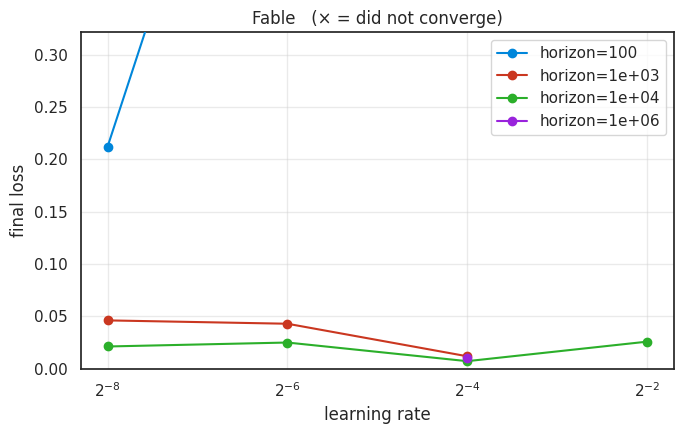

In [18]:
FABLE_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -3, 2)],   # 2^-8 .. 2^-2
    'horizon': [1e2, 1e3, 1e4],                         # the bar's aggressiveness
}
run_method_sweep(METHODS['fable'], FABLE_GRID, N_SWEEP_SEEDS, n_jobs=4)
cfgs, runs = load_sweep_data()
fable_summary = summarize_runs(cfgs, runs, 'fable', swept_vars(FABLE_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(fable_summary, swept_vars(FABLE_GRID), 'Fable')
plt.show()

[I 2026-06-13 18:29:12,443] Using an existing study with name 'feature_sifting/fable_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: c59b6408f671422c8bf80b458d07df72.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Fable best: {'learning_rate': 0.0625, 'horizon': 10000.0}
Reusing cached CSVs (196 runs, no new data to download).


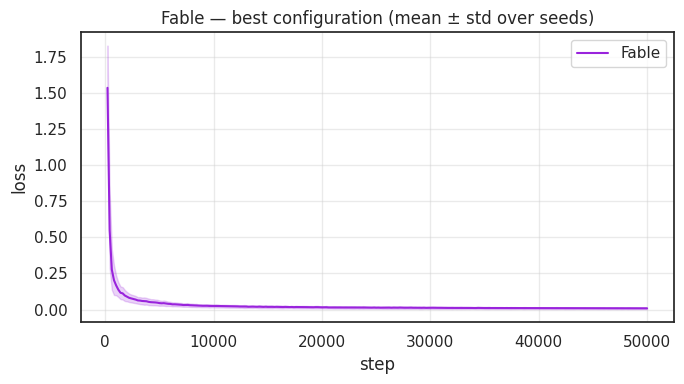

In [19]:
fable_best = best_hparams(cfgs, runs, METHODS['fable'], FABLE_GRID)
print('Fable best:', fable_best)
run_method_sweep(METHODS['fable'], fable_best, N_CURVE_SEEDS, sweep_name='fable_best')
cfgs, runs = load_sweep_data()
plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'fable_best', label='Fable', color=get_color_palette(n=4)[3])
plt.title('Fable — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## All methods — best configurations

The best configuration of each method (already run above with 30 seeds) plotted together. Data is loaded from
the cache, so this cell does not re-run any experiment.

Reusing cached CSVs (196 runs, no new data to download).


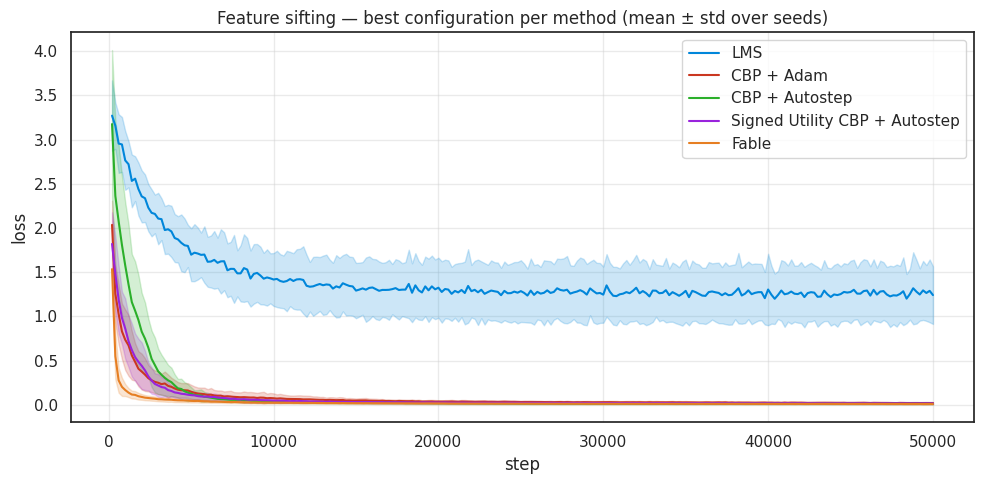

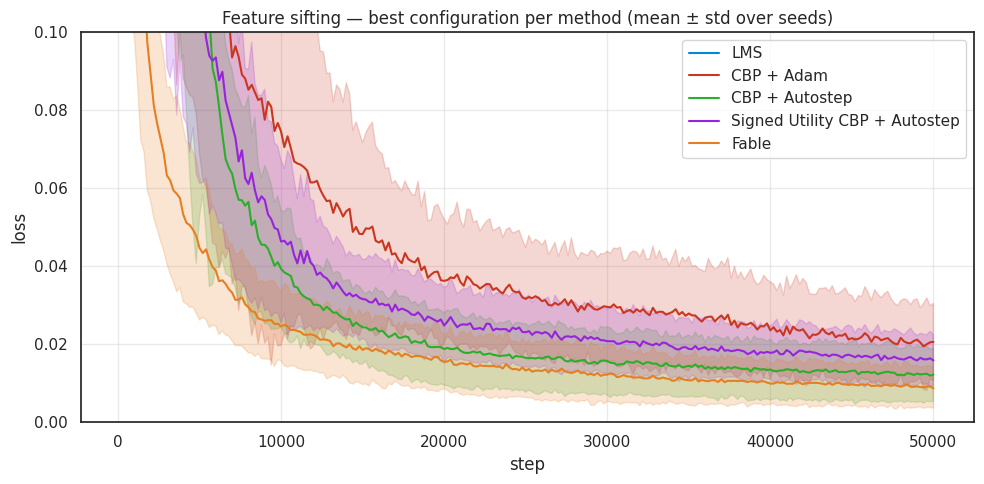

In [24]:
cfgs, runs = load_sweep_data()

best_sweeps = [(m.label, key + '_best') for key, m in METHODS.items()]
colors = get_color_palette(n=len(best_sweeps))

plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.tight_layout(); plt.show()


plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.ylim(0.0, 0.1)
plt.tight_layout(); plt.show()